# EmporiUm Sales Territory Analysis

This project analyzes sales performance for the Massachusetts (Bo Heap) and Maryland (Shruti Reddy) sales territories in the Northeast region of EmporiUm. The territories are managed by Bo Heap and Shruti Reddy. 
Using Python, Pandas, NumPy, and Matplotlib, sales data is cleaned, merged, and analyzed to evaluate revenue trends, store performance, customer spending, and product category sales.

In [452]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [453]:
store_sales = pd.read_csv("StoreSales.csv")

store_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


In [454]:
store_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [455]:
customer_list = pd.read_csv("customer_list.csv", sep="|")

customer_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


In [456]:
customer_list.head()

,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


In [457]:
product_categories = pd.read_csv("ProductCategories.csv")

product_categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


In [458]:
product_categories.head()

,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [459]:
products = pd.read_csv("Products.csv")

products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


In [460]:
products.head()

,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [461]:
store_details = pd.read_csv("StoreDetail.csv")

store_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


In [462]:
store_details.head()

,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


# Core Marketing Analysis

### 1. Who are the territory managers for the sales territories assigned? What are the store IDs and cities for the stores in each assigned sales territory?

In [463]:
# Bo Heap stores

# Primary sales territory

bo_heap_stores = store_details[store_details["Territory Manager"] == "Bo Heap"]

bo_heap_stores

,Store Location,State,Store ID,Territory Manager,Region,Region Director
52,Boston,Massachusetts,730,Bo Heap,Northeast,Michael Jarvis
53,Attleboro,Massachusetts,801,Bo Heap,Northeast,Michael Jarvis
54,Falmouth,Massachusetts,802,Bo Heap,Northeast,Michael Jarvis
55,Framingham,Massachusetts,803,Bo Heap,Northeast,Michael Jarvis
56,Haverhill,Massachusetts,804,Bo Heap,Northeast,Michael Jarvis
57,Hingham,Massachusetts,805,Bo Heap,Northeast,Michael Jarvis
58,Holyoke,Massachusetts,806,Bo Heap,Northeast,Michael Jarvis
59,Leominster,Massachusetts,807,Bo Heap,Northeast,Michael Jarvis
60,Lowell,Massachusetts,808,Bo Heap,Northeast,Michael Jarvis
61,Lynn,Massachusetts,809,Bo Heap,Northeast,Michael Jarvis


In [464]:
# Shruti Reddy Territory  

# Shruti Reddy was selected as a comparison territory because both territories are located in the Northeast region.

shruti_stores = store_details[store_details["Territory Manager"] == "Shruti Reddy"]

shruti_stores


,Store Location,State,Store ID,Territory Manager,Region,Region Director
43,Annapolis,Maryland,731,Shruti Reddy,Northeast,Michael Jarvis
44,Back River,Maryland,732,Shruti Reddy,Northeast,Michael Jarvis
45,Baltimore,Maryland,733,Shruti Reddy,Northeast,Michael Jarvis
46,Germantown,Maryland,734,Shruti Reddy,Northeast,Michael Jarvis
47,Howard,Maryland,735,Shruti Reddy,Northeast,Michael Jarvis
48,North Harford,Maryland,736,Shruti Reddy,Northeast,Michael Jarvis
49,Parkville,Maryland,737,Shruti Reddy,Northeast,Michael Jarvis
50,Queen Anne's County,Maryland,738,Shruti Reddy,Northeast,Michael Jarvis
51,Ridgely,Maryland,739,Shruti Reddy,Northeast,Michael Jarvis


### 2. What is monthly total revenue for in-store sales in each of the two sales territories, over the full period covered by the data?

In [465]:
# I merged store sales and store details data so I could connect sales transactions to specific stores and territory managers

sales_with_stores = pd.merge( store_sales, store_details, on = "Store ID")

In [466]:
bo_heap_sales = sales_with_stores[sales_with_stores["Territory Manager"] == "Bo Heap"].copy()

bo_heap_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director
79,1/1/2022,803,NaN,105422-T,116.20,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis
80,1/1/2022,803,NaN,105423-M,40.55,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis
81,1/1/2022,804,NaN,105424-T,192.26,Haverhill,Massachusetts,Bo Heap,Northeast,Michael Jarvis
82,1/1/2022,806,NaN,105345-IT,120.82,Holyoke,Massachusetts,Bo Heap,Northeast,Michael Jarvis
83,1/1/2022,806,186.0,105385-M,27.52,Holyoke,Massachusetts,Bo Heap,Northeast,Michael Jarvis


In [467]:
bo_heap_sales["Transaction Date"] = pd.to_datetime(bo_heap_sales["Transaction Date"])

bo_heap_sales["YearMonth"] = bo_heap_sales["Transaction Date"].dt.to_period("M")

## I did this to create year and month columns

In [468]:
monthly_revenue = bo_heap_sales.groupby("YearMonth")["Sale Amount"].sum()

monthly_revenue

# This gives me the monthly revenue breakdown of all BO Heaps stores month by month from Jan 2022 - Dec 2025

YearMonth
2022-01     69396.42
2022-02     65616.00
2022-03     77390.00
2022-04     81333.60
2022-05     75919.64
2022-06     81227.82
2022-07     67271.23
2022-08     73543.48
2022-09     58716.74
2022-10     72514.81
2022-11     70654.73
2022-12     70025.64
2023-01    139388.56
2023-02    104454.67
2023-03    112443.92
2023-04    109369.00
2023-05    109021.42
2023-06    101710.16
2023-07    120793.96
2023-08    126212.14
2023-09    121968.93
2023-10    113824.37
2023-11    105670.08
2023-12    101641.22
2024-01    117915.05
2024-02    103968.70
2024-03    110968.54
2024-04    107421.88
2024-05    106193.39
2024-06    116310.73
2024-07    126212.14
2024-08    123926.20
2024-09    111867.10
2024-10    110582.18
2024-11     96729.12
2024-12    139388.56
2025-01    150745.88
2025-02    140234.24
2025-03    160846.61
2025-04    156773.91
2025-05    157710.74
2025-06    170305.34
2025-07    191697.95
2025-08    174867.46
2025-09    168503.25
2025-10    277382.19
2025-11    196108.93
202

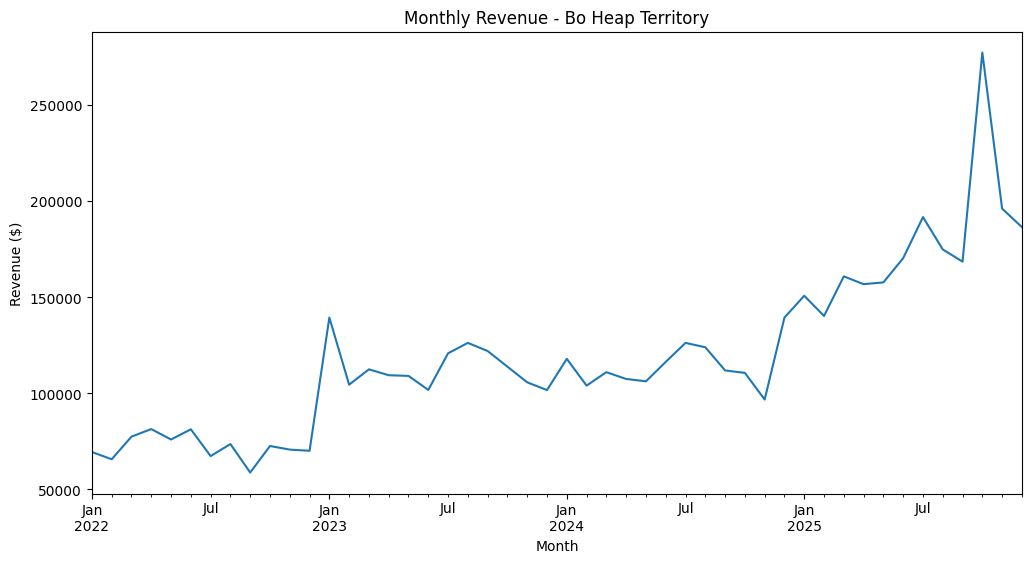

In [469]:
#Bo Heap monthly revenue chart

monthly_revenue.plot(kind="line",figsize=(12,6))

plt.title("Monthly Revenue - Bo Heap Territory")
plt.ylabel("Revenue ($)")
plt.xlabel("Month")

plt.show()

In [470]:
shruti_sales = sales_with_stores[sales_with_stores["Territory Manager"] == "Shruti Reddy"].copy()

shruti_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director
32,1/1/2022,731,NaN,105384-A,23.44,Annapolis,Maryland,Shruti Reddy,Northeast,Michael Jarvis
33,1/1/2022,733,20.0,105385-M,27.52,Baltimore,Maryland,Shruti Reddy,Northeast,Michael Jarvis
34,1/1/2022,734,NaN,105386-M,25.00,Germantown,Maryland,Shruti Reddy,Northeast,Michael Jarvis
35,1/1/2022,735,NaN,105349-M,8.00,Howard,Maryland,Shruti Reddy,Northeast,Michael Jarvis
36,1/1/2022,736,NaN,105310-IT,71.74,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis


In [471]:
shruti_sales["Transaction Date"] = pd.to_datetime(shruti_sales["Transaction Date"])

shruti_sales["YearMonth"] = shruti_sales["Transaction Date"].dt.to_period("M")

In [472]:
shruti_monthly_revenue = shruti_sales.groupby("YearMonth")["Sale Amount"].sum()

shruti_monthly_revenue

shruti_monthly_revenue

YearMonth
2022-01    190064.90
2022-02    197529.18
2022-03    210228.48
2022-04    179004.18
2022-05    212028.70
2022-06    198318.98
2022-07    231208.13
2022-08    203503.40
2022-09    158952.74
2022-10    200423.07
2022-11    202365.13
2022-12    226340.81
2023-01    247207.80
2023-02    215146.55
2023-03    212397.10
2023-04    253354.48
2023-05    236271.38
2023-06    243603.42
2023-07    218664.85
2023-08    233256.77
2023-09    227638.37
2023-10    248095.23
2023-11    242019.94
2023-12    236037.31
2024-01    234650.29
2024-02    200891.75
2024-03    263664.98
2024-04    225960.88
2024-05    248901.48
2024-06    213366.79
2024-07    233256.77
2024-08    234863.77
2024-09    240869.83
2024-10    247456.61
2024-11    230600.64
2024-12    247207.80
2025-01    277874.74
2025-02    262318.88
2025-03    293722.84
2025-04    206982.63
2025-05    225774.67
2025-06    216983.57
2025-07    310327.16
2025-08    311949.14
2025-09    304304.79
2025-10    359699.69
2025-11    304194.50
202

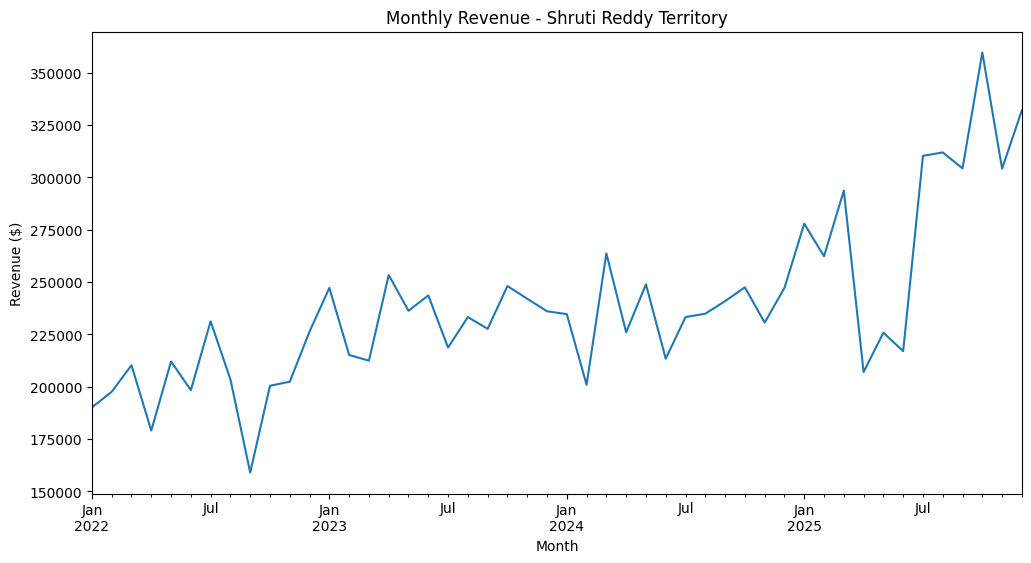

In [473]:
# Shruti Reddy Monthly revenue chart

shruti_monthly_revenue.plot(kind="line",figsize=(12,6))

plt.title("Monthly Revenue - Shruti Reddy Territory")
plt.ylabel("Revenue ($)")
plt.xlabel("Month")

plt.show()

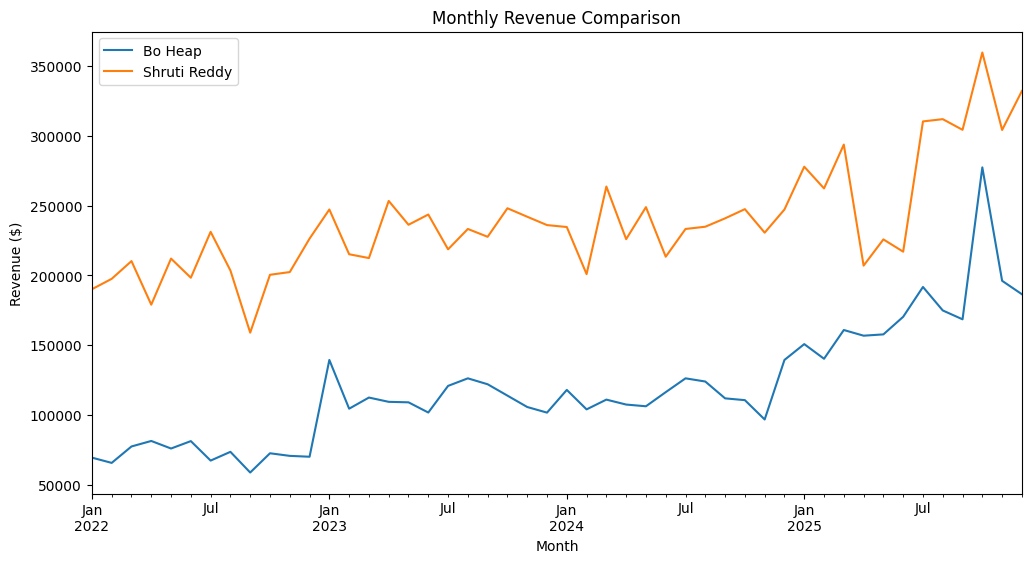

In [474]:
# Bo Heap vs Shruti comparioson chart
# This chart compares monthly revenue trends between Bo Heap's territory and Shruti Reddy's territory, 
# making it easier to see differences in sales performance over time

plt.figure(figsize=(12,6))

monthly_revenue.plot(label="Bo Heap")

shruti_monthly_revenue.plot(label="Shruti Reddy")

plt.title("Monthly Revenue Comparison")
plt.ylabel("Revenue ($)")
plt.xlabel("Month")

plt.legend()

plt.show()

### 3. How would you rank the sales performance of each store in each sales territory? Which are the top performing stores?

In [475]:
# Bo Heap store rankings
store_performance = bo_heap_sales.groupby(["Store ID", "Store Location"])["Sale Amount"].sum().sort_values(ascending = False)

store_performance

# I grouped by both Store ID and Store Location to make sure each store was ranked individually and no locations were accidentally combined.
# The top performing stores arew 817, 807, and 810

Store ID  Store Location
817       Worcester         602183.44
807       Leominster        338009.10
810       Nantucket         335547.81
814       Provincetown      328860.51
812       Northampton       322039.24
806       Holyoke           320516.53
816       Somerville        312873.59
804       Haverhill         305762.60
809       Lynn              302049.65
813       Pittsfield        301281.50
811       New Bedford       295443.42
730       Boston            295201.29
801       Attleboro         290883.71
805       Hingham           289633.52
815       Quincy            279646.07
802       Falmouth          276965.55
803       Framingham        269375.91
808       Lowell            266982.83
Name: Sale Amount, dtype: float64

In [476]:
top_10_bo_stores = store_performance.head(10)

top_10_bo_stores

Store ID  Store Location
817       Worcester         602183.44
807       Leominster        338009.10
810       Nantucket         335547.81
814       Provincetown      328860.51
812       Northampton       322039.24
806       Holyoke           320516.53
816       Somerville        312873.59
804       Haverhill         305762.60
809       Lynn              302049.65
813       Pittsfield        301281.50
Name: Sale Amount, dtype: float64

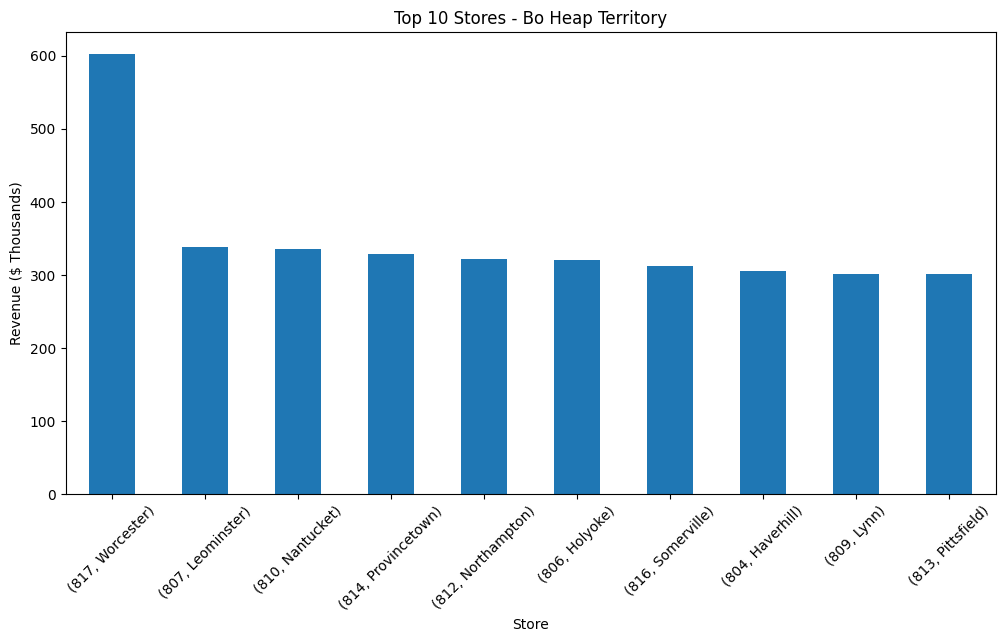

In [477]:
(top_10_bo_stores / 1000).plot(kind="bar",figsize=(12,6))

plt.title("Top 10 Stores - Bo Heap Territory")
plt.ylabel("Revenue ($ Thousands)")
plt.xlabel("Store")

plt.xticks(rotation=45)

plt.show()

In [478]:
# Shruti Reddy store rankings

shruti_store_performance = shruti_sales.groupby(["Store ID", "Store Location"])["Sale Amount"].sum().sort_values(ascending=False)

shruti_store_performance

Store ID  Store Location     
736       North Harford          8708119.00
734       Germantown              584675.92
737       Parkville               320441.24
735       Howard                  319394.58
739       Ridgely                 318511.04
733       Baltimore               310099.90
732       Back River              303433.61
738       Queen Anne's County     298074.49
731       Annapolis               288865.31
Name: Sale Amount, dtype: float64

In [479]:
top_10_shruti_stores = shruti_store_performance.head(10)

top_10_shruti_stores

Store ID  Store Location     
736       North Harford          8708119.00
734       Germantown              584675.92
737       Parkville               320441.24
735       Howard                  319394.58
739       Ridgely                 318511.04
733       Baltimore               310099.90
732       Back River              303433.61
738       Queen Anne's County     298074.49
731       Annapolis               288865.31
Name: Sale Amount, dtype: float64

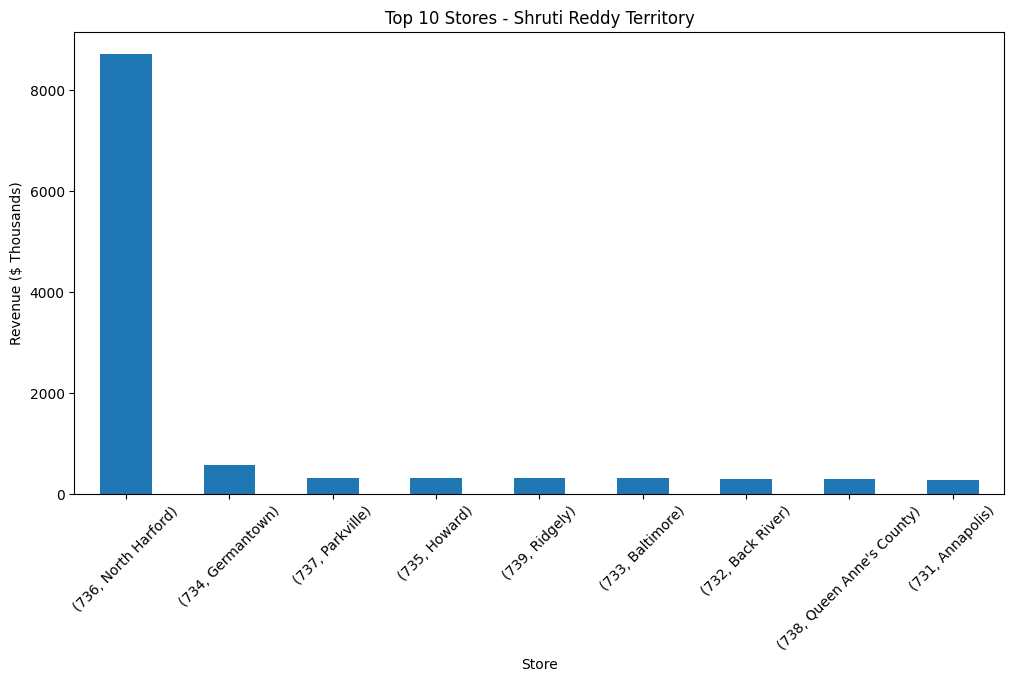

In [480]:
(top_10_shruti_stores / 1000).plot(kind="bar",figsize=(12,6))

plt.title("Top 10 Stores - Shruti Reddy Territory")
plt.ylabel("Revenue ($ Thousands)")
plt.xlabel("Store")

plt.xticks(rotation=45)

plt.show()

##### The store rankings show the highest-performing stores in each territory based on total sales revenue. Comparing the rankings helps identify which stores contribute most to overall territory performance.

### 4. Comparing the customer ID from the customer list data with the rewards ID from the sales data, who were the top customers in each sales territory?

In [481]:
# To identify the top customers in each territory, 
# customer information was joined with the sales data by matching the customer ID on the customer list
#  with the RewardsID from the sales transactions.

In [482]:
# Bo Heap Merge

customer_sales = pd.merge(bo_heap_sales,customer_list,
    left_on="RewardsID",
    right_on="cust_id")

customer_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,YearMonth,cust_id,date,time,name,email,phone,sms-opt-out
0,2022-01-01,806,186.0,105385-M,27.52,Holyoke,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022-01,186,2023-02-25,09:50:20,Olivia Pope,olivia@oliviapopeandassociates.com,202-555-1201,N
1,2022-01-01,814,327.0,105427-S,10.16,Provincetown,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022-01,327,2023-04-10,10:30:50,John Doggett,doggett@fbi.gov,202-555-1306,N
2,2022-01-02,801,243.0,105262-IT,603.50,Attleboro,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022-01,243,2024-01-03,18:40:00,Dayanara Diaz,daya@litchfield.pen,607-555-1708,N
3,2022-01-02,817,184.0,105457-IT,29.81,Worcester,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022-01,184,2023-12-16,21:50:15,Stan Winters,stan@wzhup.det,313-555-1109,N
4,2022-01-02,817,321.0,105365-T,221.48,Worcester,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022-01,321,2023-08-03,20:05:20,Serenity,serenity@serenity.ship,042-555-1210,N


In [483]:
# Bo Heap top 10 customers

top_customers = customer_sales.groupby(["cust_id", "name"])["Sale Amount"].sum().sort_values( ascending=False).head(10)

top_customers

cust_id  name           
292      Beverly Crusher    4758.92
384      Tracy Jordan       4197.55
47       Stanley H.         3979.73
3        Monica Geller      3966.91
188      Mellie Grant       3948.41
300      Julian Bashir      3883.60
17       Mike E.            3788.67
316      Kaylee Frye        3725.87
344      Nate Jacobs        3569.36
178      Pamela James       3523.01
Name: Sale Amount, dtype: float64

In [484]:
shruti_customer_sales = pd.merge(shruti_sales,customer_list,
    left_on="RewardsID",
    right_on="cust_id")

shruti_customer_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,YearMonth,cust_id,date,time,name,email,phone,sms-opt-out
0,2022-01-01,733,20.0,105385-M,27.52,Baltimore,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,20,2023-09-09,18:40:15,Lydia R.,lydia@lospolloshermanos.biz,505-555-2010,N
1,2022-01-01,736,131.0,105387-A,27.52,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,131,2023-08-30,11:35:35,Elizabeth W.,elizabeth@generalhospital.med,716-555-9606,N
2,2022-01-01,736,289.0,105389-S,12.40,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,289,2023-05-10,19:15:45,Geordi La Forge,geordi@enterprise.starfleet,1701-555-2204,N
3,2022-01-01,736,334.0,105400-B,76.40,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,334,2023-06-12,17:20:05,James Ford,sawyer@dharma.initiative,808-555-1403,N
4,2022-01-01,736,281.0,105418-B,20.36,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,281,2023-09-22,13:30:30,Will Reeves,hoodedjustice@keenecounty.police,918-555-2106,N


In [485]:
top_10_shruti_customers = shruti_customer_sales.groupby(["cust_id", "name"])["Sale Amount"].sum().sort_values(ascending=False).head(10)

top_10_shruti_customers

cust_id  name           
180      Cole Brown         7602.28
355      Donna Hayward      7081.17
467      Avon Barksdale     6172.68
99       Trent Lane         6076.89
75       Magnitude          5916.81
349      Fezco              5795.71
400      K. McClanahan      5674.84
419      Count von Count    5650.21
283      Joe Keene Jr.      5153.18
137      Nikki N.           5139.67
Name: Sale Amount, dtype: float64

### 5. What is the number of transactions per month by product category in each assigned territory? What is total sales revenue per month by category? What might this tell you about the most popular products, and where could there be opportunity for growth?

In [486]:
# Merged the sales data with the product data using Product Number so I could see which products were being purchased

bo_products = pd.merge(bo_heap_sales,products,
    on = "Prod Num")

bo_products.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,YearMonth,Product,CategoryID,SubcategoryID
0,2022-01-01,803,NaN,105422-T,116.20,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022-01,Abstract Algebra,100,100-mat
1,2022-01-01,803,NaN,105423-M,40.55,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022-01,"LTCA Year Up Coasters (Set of 4, Cork)",130,130-hom
2,2022-01-01,804,NaN,105424-T,192.26,Haverhill,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022-01,Organic Chemistry I,100,100-sci
3,2022-01-01,806,NaN,105345-IT,120.82,Holyoke,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022-01,Razer Kraken X,120,120-hea
4,2022-01-01,806,186.0,105385-M,27.52,Holyoke,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022-01,LTCA Year Up Foam Finger (Black),130,130-spo


In [487]:
# # Merged using CategoryID and SubcategoryID

bo_products_categories = pd.merge(bo_products,product_categories,
    on=["CategoryID", "SubcategoryID"])


bo_products_categories.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,YearMonth,Product,CategoryID,SubcategoryID,Category,Subcategory
0,2022-01-01,803,NaN,105422-T,116.20,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022-01,Abstract Algebra,100,100-mat,Textbooks,Math and Statistics
1,2022-01-01,803,NaN,105423-M,40.55,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022-01,"LTCA Year Up Coasters (Set of 4, Cork)",130,130-hom,Apparel and Merchandise,Home and Decor
2,2022-01-01,804,NaN,105424-T,192.26,Haverhill,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022-01,Organic Chemistry I,100,100-sci,Textbooks,Science
3,2022-01-01,806,NaN,105345-IT,120.82,Holyoke,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022-01,Razer Kraken X,120,120-hea,Technology & Accessories,Headphones
4,2022-01-01,806,186.0,105385-M,27.52,Holyoke,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022-01,LTCA Year Up Foam Finger (Black),130,130-spo,Apparel and Merchandise,Sports and Outdoor Gear


In [488]:
# I counted the number of transactions in each category to see which categories were purchased more often

bo_transactions = bo_products_categories.groupby("Category")["Sale Amount"].count().sort_values(
    ascending=False)

bo_transactions

Category
Stationery and Supplies     9019
Technology & Accessories    8724
Apparel and Merchandise     8314
Art Supplies                7865
Textbooks                   5789
Books (General)             3409
Name: Sale Amount, dtype: int64

In [489]:
# Summed the sales revenue for each category to see which category had the most revenue

bo_category_revenue = bo_products_categories.groupby("Category")["Sale Amount"].sum().sort_values(
    ascending=False)

bo_category_revenue

Category
Technology & Accessories    4059863.21
Textbooks                    998901.78
Apparel and Merchandise      266531.69
Art Supplies                 246064.01
Books (General)               99532.89
Stationery and Supplies       91211.24
Name: Sale Amount, dtype: float64

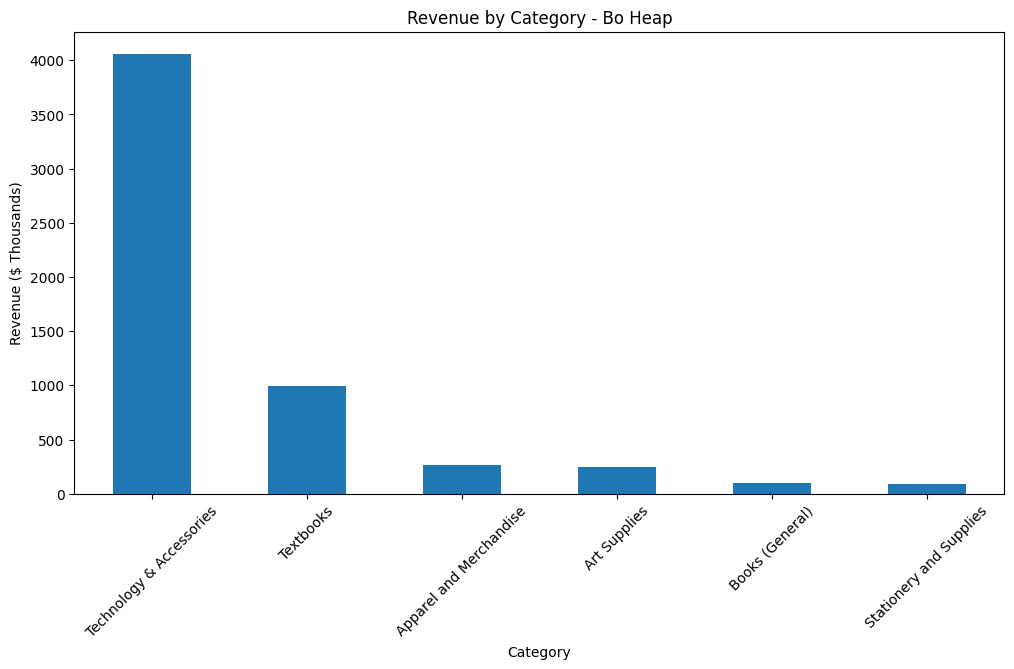

In [490]:
(bo_category_revenue / 1000).plot(kind="bar", figsize=(12,6))

plt.title("Revenue by Category - Bo Heap")
plt.ylabel("Revenue ($ Thousands)")
plt.xlabel("Category")

plt.xticks(rotation=45)

plt.show()

In [491]:
shruti_products = pd.merge(shruti_sales,products,
    on="Prod Num")

shruti_products.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,YearMonth,Product,CategoryID,SubcategoryID
0,2022-01-01,731,NaN,105384-A,23.44,Annapolis,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,Silver Brush Limited Ruby Satin Brushes (Set o...,115,115-pai
1,2022-01-01,733,20.0,105385-M,27.52,Baltimore,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,LTCA Year Up Foam Finger (Black),130,130-spo
2,2022-01-01,734,NaN,105386-M,25.00,Germantown,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,LTCA Year Up Graduation Sash,130,130-mem
3,2022-01-01,735,NaN,105349-M,8.00,Howard,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,LTCA Year Up Gel Pen (Pack of 2),130,130-off
4,2022-01-01,736,NaN,105310-IT,71.74,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,Anker PowerExpand USB-C Dock,120,120-ext


In [492]:
shruti_products_categories = pd.merge(shruti_products,product_categories,
    on=["CategoryID", "SubcategoryID"])

shruti_products_categories.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,YearMonth,Product,CategoryID,SubcategoryID,Category,Subcategory
0,2022-01-01,731,NaN,105384-A,23.44,Annapolis,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,Silver Brush Limited Ruby Satin Brushes (Set o...,115,115-pai,Art Supplies,Paint Brushes
1,2022-01-01,731,NaN,105384-A,23.44,Annapolis,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,Silver Brush Limited Ruby Satin Brushes (Set o...,115,115-pai,Art Supplies,Paints
2,2022-01-01,733,20.0,105385-M,27.52,Baltimore,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,LTCA Year Up Foam Finger (Black),130,130-spo,Apparel and Merchandise,Sports and Outdoor Gear
3,2022-01-01,734,NaN,105386-M,25.00,Germantown,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,LTCA Year Up Graduation Sash,130,130-mem,Apparel and Merchandise,Memorabilia and Collectibles
4,2022-01-01,735,NaN,105349-M,8.00,Howard,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,LTCA Year Up Gel Pen (Pack of 2),130,130-off,Apparel and Merchandise,Office and Study Supplies


In [493]:
shruti_transactions = shruti_products_categories.groupby("Category")["Sale Amount"].count().sort_values(
    ascending=False)

shruti_transactions

Category
Technology & Accessories    16836
Stationery and Supplies     16655
Art Supplies                15674
Apparel and Merchandise     15547
Books (General)             15335
Textbooks                   11639
Name: Sale Amount, dtype: int64

In [494]:
shruti_category_revenue = shruti_products_categories.groupby("Category")["Sale Amount"].sum().sort_values(
    ascending=False)

shruti_category_revenue

Category
Technology & Accessories    7826937.84
Textbooks                   2021177.87
Apparel and Merchandise      500587.47
Books (General)              494845.76
Art Supplies                 493114.72
Stationery and Supplies      174069.48
Name: Sale Amount, dtype: float64

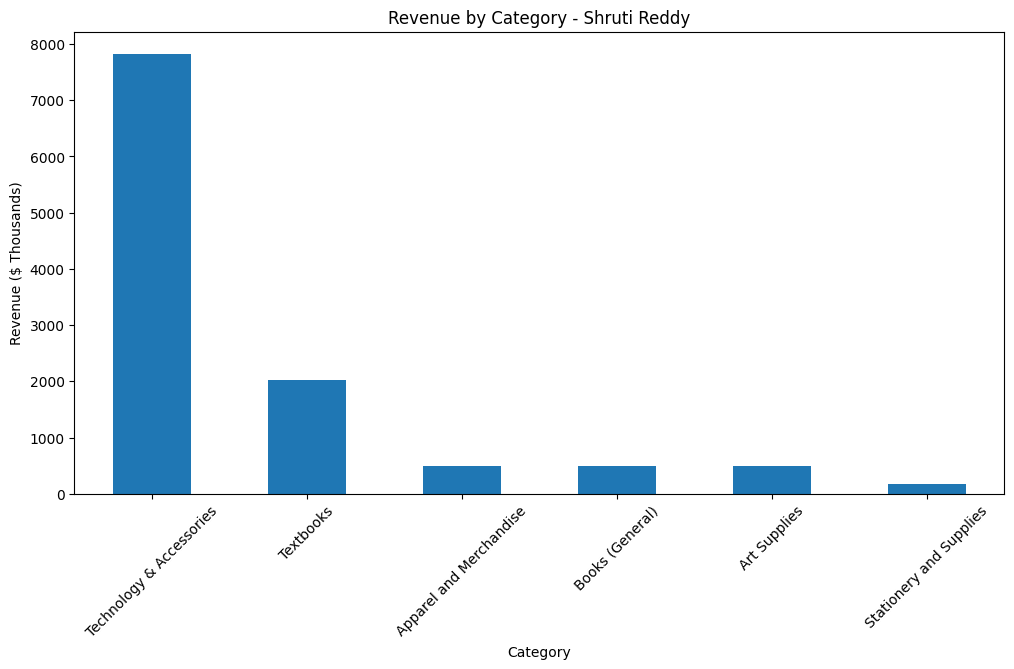

In [ ]:
(shruti_category_revenue / 1000).plot(kind="bar",figsize=(12,6))

plt.title("Revenue by Category - Shruti Reddy")
plt.ylabel("Revenue ($ Thousands)")
plt.xlabel("Category")

plt.xticks(rotation=45)

plt.show()

Technology & Accessories generated the most revenue in both territories, while Technology & Accessories and Stationery and Supplies had the most transactions. This shows strong customer demand in those categories, while lower-performing categories may offer opportunities for growth.


### 6. What is your recommendation for where to focus marketing attention in the next quarter?

Based on my analysis, I would recommend focusing marketing on the strongest performing stores, highest value customers, and top product categories in each territory.

The store performance analysis shows which locations are producing the most revenue. These stores are good locations for promotions because they already have strong customer activity. The customer analysis also shows that rewards members are important because top customers generated strong total spending in each territory.

The product category analysis showed which category customers are purchasing most from and which category generates the most revenue. Marketing should continue supporting these high performing categories by targeting promotions and seasonal campaigns. Lower performing categories should be reviewed to see if any growth opportunities are availble like discounts, bundles, or improved product visibility.

Overall, the data shows that EmporiUm should focus on customer retention, category based promotions, and supporting top performing stores to increase revenue in the next quarter.